---
title: "COASTAL ZONE CONCEPTUALIZATION REPORT"
format:
  html:
    embed-resources: true
    theme: cosmo
execute:
  echo: false
---

In [20]:
#| include: false

import pandas as pd

file_name = 'Revised Data_Conceptulaization of Coastal Zone.xlsx - Normalized Data.csv'
df = pd.read_csv(file_name, header=None)


df[0] = df[0].ffill()


group_mapping = {
    'KI (n=15)': {'theme_total': 2, 'core_idea': 3},
    'Experts (n=29)': {'theme_total': 4, 'core_idea': 5},
    'LCM (n=68)': {'theme_total': 6, 'core_idea': 7},
    'Interviews (n=47)': {'theme_total': 9, 'core_idea': 10},
    'Workshops (n=65)': {'theme_total': 11, 'core_idea': 12},
    'Female (n=14)': {'theme_total': 14, 'core_idea': 15},
    'Male (n=33)': {'theme_total': 16, 'core_idea': 17}
}

tidy_data = []

for i in range(2, len(df)):
    row = df.iloc[i]
    

    raw_theme = str(row[0]).strip()
    raw_sub = str(row[1]).strip().rstrip(')')
    

    if pd.isna(row[1]) or str(row[1]).lower() == 'nan':
        continue

    for group_name, cols in group_mapping.items():

        try:
            core_val = str(row[cols['core_idea']]).replace('%', '').strip()
            if core_val and core_val.lower() != 'nan':
                tidy_data.append({
                    'Theme': raw_theme,
                    'Category_Type': 'Sub-category',
                    'Item': raw_sub,
                    'Group': group_name,
                    'Frequency (%)': float(core_val)
                })
        except (ValueError, TypeError):
            pass


        try:
            theme_val_str = str(row[cols['theme_total']]).replace('%', '').strip()
            if theme_val_str and theme_val_str.lower() != 'nan':
                tidy_data.append({
                    'Theme': raw_theme,
                    'Category_Type': 'Theme Total',
                    'Item': f"TOTAL: {raw_theme}",
                    'Group': group_name,
                    'Frequency (%)': float(theme_val_str)
                })
        except (ValueError, TypeError):
            pass


final_tidy_df = pd.DataFrame(tidy_data)
final_tidy_df.to_csv('Wrangled_Revised Data.csv', index=False)

print("Wrangling complete. Cleaned data saved to: Wrangled_Revised Data.csv")

Wrangling complete. Cleaned data saved to: Wrangled_Revised Data.csv


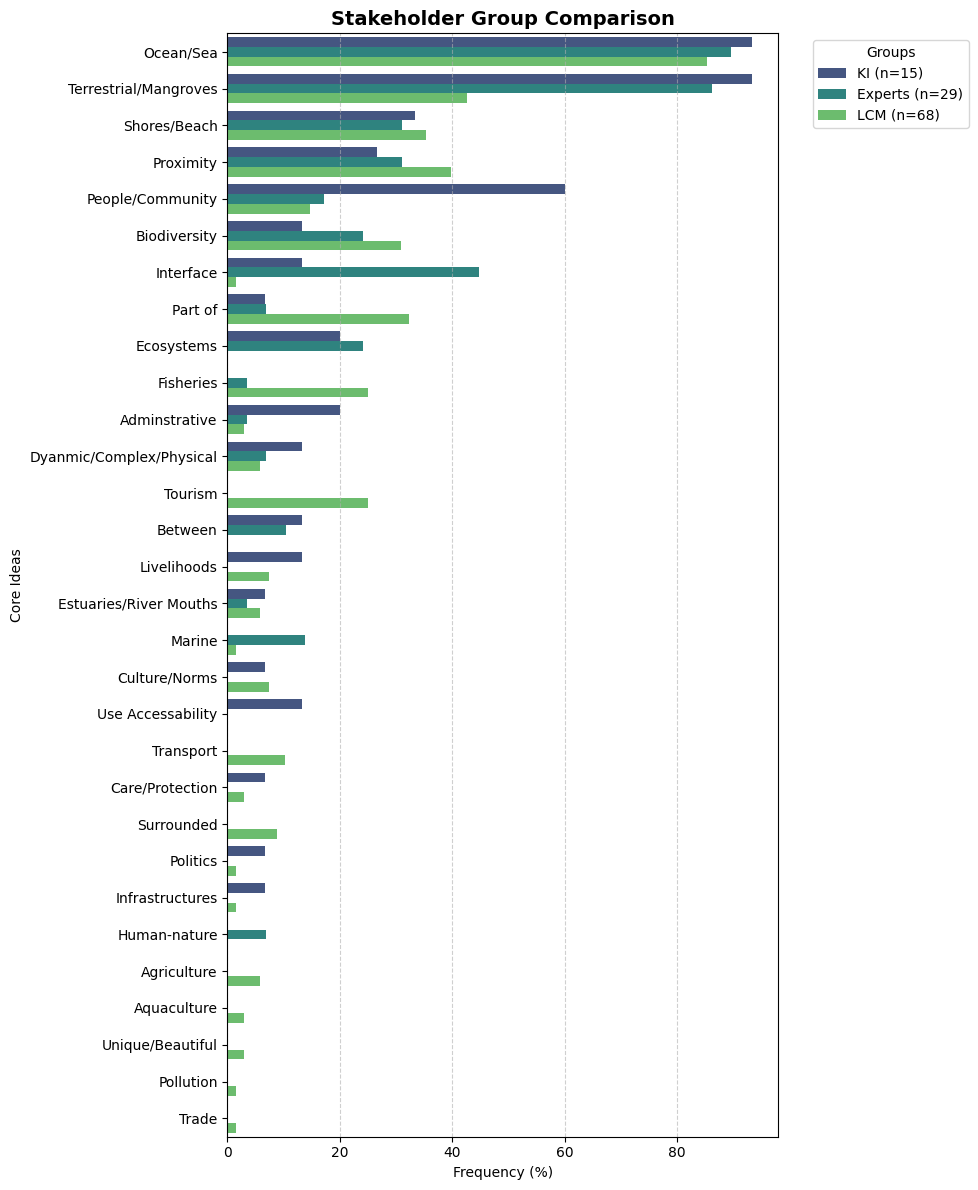

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

matplotlib.use('module://matplotlib_inline.backend_inline')

df = pd.read_csv('Wrangled_Revised Data.csv')
subcat_df = df[df['Category_Type'] == 'Sub-category'].copy()

stakeholders = ['KI (n=15)', 'Experts (n=29)', 'LCM (n=68)']
data = subcat_df[subcat_df['Group'].isin(stakeholders)]
order = data.groupby('Item')['Frequency (%)'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(data=data, x='Frequency (%)', y='Item', hue='Group', palette='viridis', order=order)

plt.title('Stakeholder Group Comparison', fontsize=14, weight='bold')
plt.xlabel('Frequency (%)')
plt.ylabel('Core Ideas')
plt.legend(title='Groups', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('stakeholder_comparison_final.png', dpi=300)
plt.show()

Key Informants (KI) and Experts show a highly technical and academic focus, with Ocean/Sea and Marine Ecosystems reaching near-universal frequency.
Local Community Members (LCM) prioritize socio-economic and practical aspects, significantly outperforming experts in Resource/Livelihood and Tourism.
Experts view the coast as a biological system, while locals define it through its capacity to support human activity and survival.

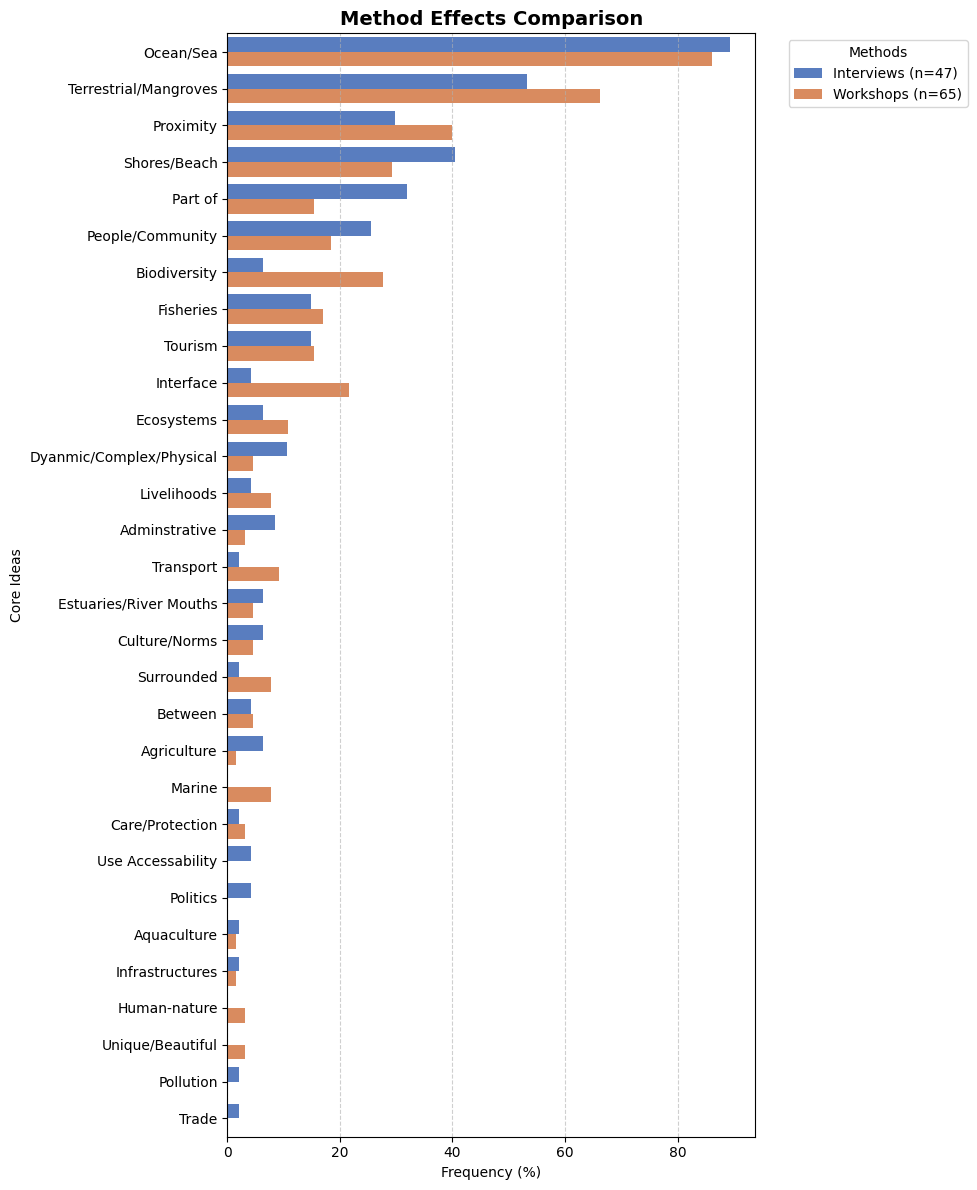

In [22]:
df = pd.read_csv('Wrangled_Revised Data.csv')
subcat_df = df[df['Category_Type'] == 'Sub-category'].copy()

methods = ['Interviews (n=47)', 'Workshops (n=65)']
data = subcat_df[subcat_df['Group'].isin(methods)]
order = data.groupby('Item')['Frequency (%)'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(data=data, x='Frequency (%)', y='Item', hue='Group', palette='muted', order=order)

plt.title('Method Effects Comparison', fontsize=14, weight='bold')
plt.xlabel('Frequency (%)')
plt.ylabel('Core Ideas')
plt.legend(title='Methods', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('method_effects_comparison_final.png', dpi=300)
plt.show()

Workshops fostered higher frequencies in Governance, Policy, and Socio-economic categories, suggesting group settings trigger consensus on collective management.
Interviews yielded higher mentions of specific Marine Ecosystems and Ocean/Sea elements, likely due to the focused, individual nature of the dialogue allowing for detailed environmental descriptions.
While workshops are superior for identifying shared social norms and management priorities, individual interviews are more effective for capturing detailed and diverse environmental knowledge.

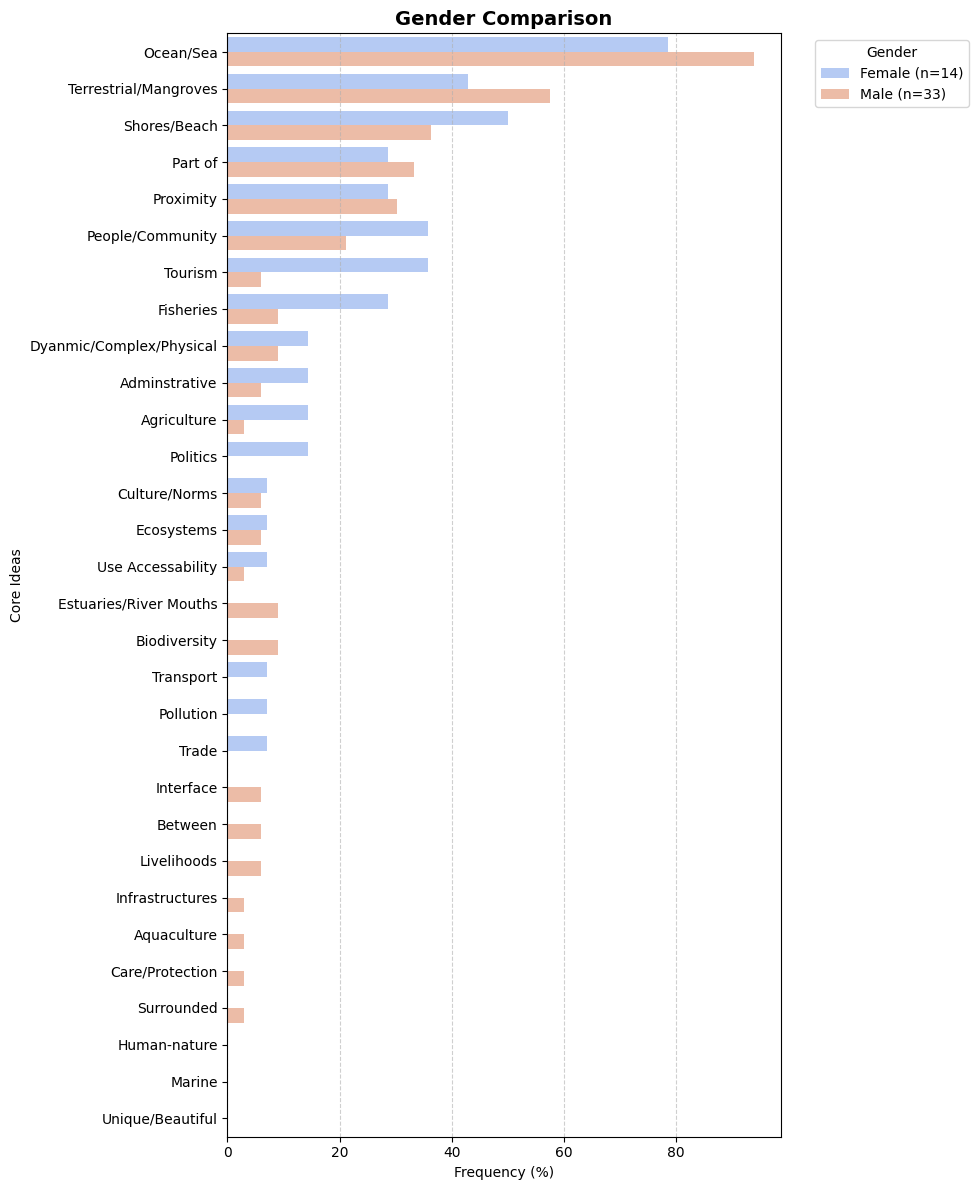

In [23]:
df = pd.read_csv('Wrangled_Revised Data.csv')
subcat_df = df[df['Category_Type'] == 'Sub-category'].copy()

gender = ['Female (n=14)', 'Male (n=33)']
data = subcat_df[subcat_df['Group'].isin(gender)]
order = data.groupby('Item')['Frequency (%)'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(data=data, x='Frequency (%)', y='Item', hue='Group', palette='coolwarm', order=order)

plt.title('Gender Comparison', fontsize=14, weight='bold')
plt.xlabel('Frequency (%)')
plt.ylabel('Core Ideas')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('gender_comparison_final.png', dpi=300)
plt.show()

Gender Comparison highlights subtle differences in coastal conceptualization. Both genders strongly identify the coast with Ocean/Sea and Marine Ecosystems.
However, female participants show a higher frequency in mentioning livelihood, governance, and policy aspects, while male participants lean more toward resources and specific physical features.
This suggests that female respondents may view the coastal zone through a lens of management and social stability, whereas male respondents focus on the physical and extractive utility of the space.

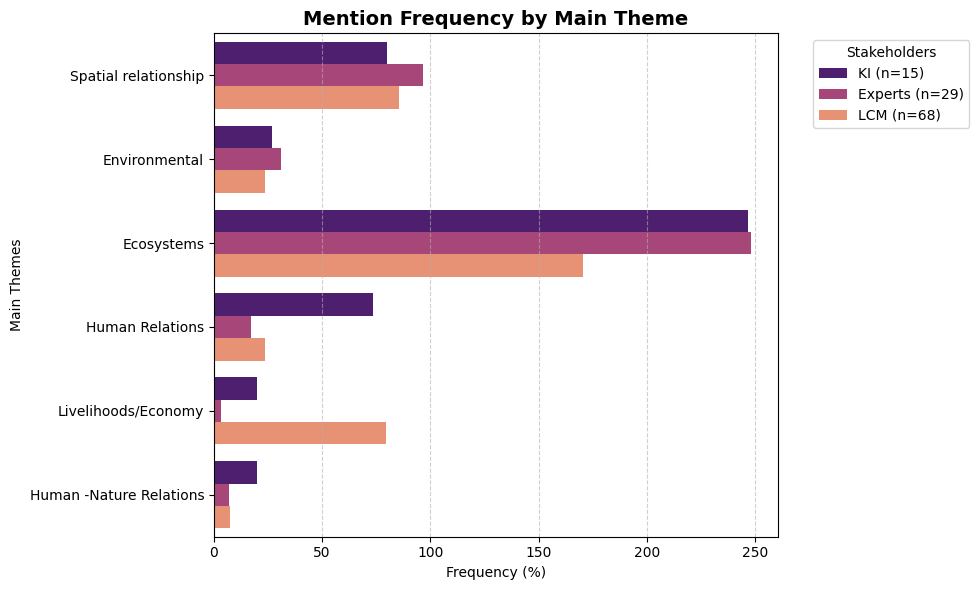

In [24]:
df = pd.read_csv('Wrangled_Revised Data.csv')
theme_df = df[df['Category_Type'] == 'Theme Total'].copy()
theme_df['Item'] = theme_df['Item'].str.replace('TOTAL: ', '')

stakeholders = ['KI (n=15)', 'Experts (n=29)', 'LCM (n=68)']
data = theme_df[theme_df['Group'].isin(stakeholders)]

plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='Frequency (%)', y='Item', hue='Group', palette='magma')

plt.title('Mention Frequency by Main Theme', fontsize=14, weight='bold')
plt.xlabel('Frequency (%)')
plt.ylabel('Main Themes')
plt.legend(title='Stakeholders', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('theme_overview_final.png', dpi=300)
plt.show()

Ecosystems serves as the universal primary anchor across all groups.
Spatial Relationshipis (boundary and proximity) is the second most significant theme, outperforming Environmental category, indicating that participants define the coast more by its geographical interface than by broader environmental traits.
While Livelihoods/Economy remains a critical functional priority for local communities, it is secondary for technical stakeholders.
Finally, the lower frequency of Human Relations and Human-Nature Relations suggests that institutional governance is less central to the common conceptualization than physical and economic attributes.